## observation data 

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [5]:
plt.style.use('dark_background')

### Functions needed for the analysis

In [6]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
import matplotlib.patches as mpatches

def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
        
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = 'horizontal', shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [7]:
from functions import preproc_funcs as funcs

In [8]:
from functions import xr_lowess

In [9]:
obs_sst = xr.open_dataset('../seasonal_period_analysis/data/obs/ersst_v5.nc').sst.resample(time = 'AS-JUN').mean('time')
obs_sst_anom = funcs.calc_anom_annual(obs_sst, obs_sst.sel(time = slice('1960', '1990')))

In [10]:
# obs_sst_anom_det = funcs.detrend_separate_check(obs_sst_anom, dim='time', period=30)

In [11]:
# obs_sst_anom_det

In [10]:
obs_trend = funcs.calc_trend3d(obs_sst_anom.sel(time = slice('1980', '2014')), 'time')
obs_pval = funcs.calc_trend_pval3d(obs_sst_anom.sel(time = slice('1980', '2014')), 'time')

In [11]:
# obs_trend_det = funcs.calc_trend3d(obs_sst_anom_det.sel(time = slice('1980', '2022')), 'time')
# obs_pval_det = funcs.calc_trend_pval3d(obs_sst_anom_det.sel(time = slice('1980', '2022')), 'time')

In [12]:
# obs_trend2 = funcs.calc_trend3d(obs_sst_anom.sel(time = slice('1920', '1960')), 'time')
# obs_pval2 = funcs.calc_trend_pval3d(obs_sst_anom.sel(time = slice('1920', '1960')), 'time')

In [13]:
xx, yy = np.meshgrid(obs_trend.lon, obs_trend.lat)

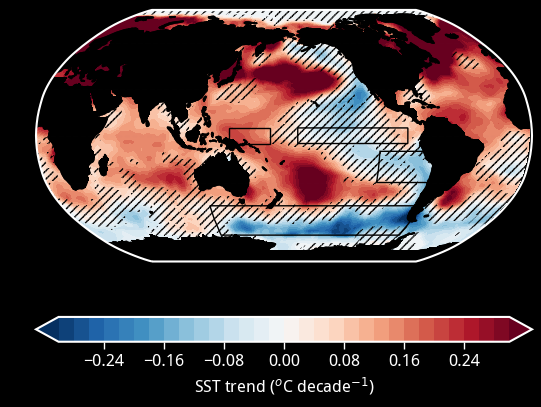

In [14]:
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
plot_background(ax)
ax.add_feature(cfeature.LAND, color='k', zorder=2)
zz = np.ma.masked_less_equal(obs_pval, 0.05)
obs_trend.plot.contourf(cmap='RdBu_r', levels=np.arange(-0.3, 0.32, 0.02), extend='both', transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='horizontal', label='SST trend ($^{o}$C decade$^{-1}$)'))
ax.pcolor(xx, yy, zz, alpha=0., hatch='////', transform=ccrs.PlateCarree())
ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

plt.savefig('./images/obs.png', dpi=300, bbox_inches='tight')


In [15]:
weights = np.cos(np.deg2rad(obs_sst_anom.lat))

In [16]:
obs_nino34_index = funcs.detrend_separate_check(obs_sst_anom.sel(lat = slice(5,-5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), dim='time', period=15)
# obs_nino3_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(-150+360, -90+360)).weighted(weights).mean(('lat', 'lon'))
# obs_nino4_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(160, -150+360)).weighted(weights).mean(('lat', 'lon'))
obs_wp_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
obs_ct_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
obs_so_sst = obs_sst_anom.sel(lat = slice(-45, -65), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

In [17]:
obs_nino34_index.sel(time = slice('1980', '2014')).std()

<xarray.DataArray 'sst' ()>
array(0.76884083)

In [18]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    res = STL(x, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

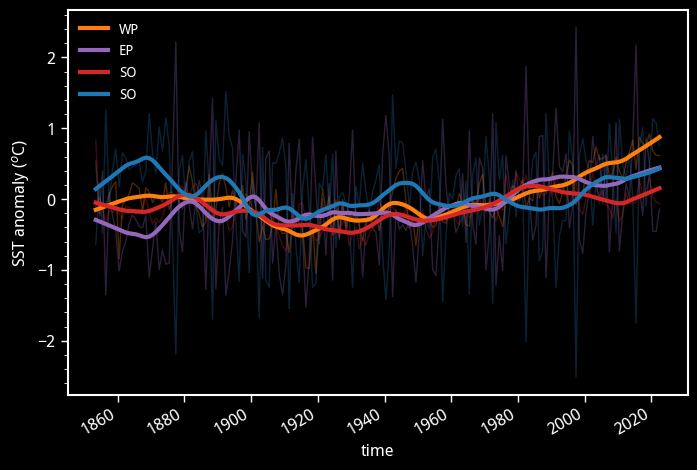

In [19]:
plt.figure(figsize=(8,5))
plt.axhline(0.0, color='k', lw=0.5)
(obs_wp_sst.sel(time = slice('1850', '2022'))).plot(color='tab:orange', lw=1.0, alpha=0.3)
(obs_ct_sst.sel(time = slice('1850', '2022'))).plot(color='tab:purple', lw=1.0, alpha=0.3)
(obs_so_sst.sel(time = slice('1850', '2022'))).plot(color='tab:red', lw=1.0, alpha=0.3)
(obs_wp_sst.sel(time = slice('1850', '2022')) - obs_ct_sst.sel(time = slice('1850', '2022'))).plot(color='tab:blue', lw=1.0, alpha=0.3)

loess3d(obs_wp_sst.sel(time = slice('1850', '2022')), dim='time', period=10).plot(color='tab:orange', lw=3.0, label='WP')
loess3d(obs_ct_sst.sel(time = slice('1850', '2022')), dim='time', period=10).plot(color='tab:purple', lw=3.0, label='EP')
loess3d(obs_so_sst.sel(time = slice('1850', '2022')), dim='time', period=10).plot(color='tab:red', lw = 3.0, label='SO')
loess3d(obs_wp_sst.sel(time = slice('1850', '2022')) - obs_ct_sst.sel(time = slice('1850', '2022')), dim='time', period=10).plot(color='tab:blue', lw = 3.0, label='SO')
plt.minorticks_on()
plt.gca().tick_params(axis='x', which='minor', bottom=False)
plt.ylabel('SST anomaly ($^{o}$C)')
plt.legend(frameon=False, fontsize=10)

In [20]:
import glob
import multiprocessing as mp

In [21]:
# Function to find the first file in each model's r1* directory
def find_all_files(pattern):
    all_paths = glob.glob(pattern)
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        model_identifier = path_parts[7]
        if model_identifier not in model_files:
            model_files[model_identifier] = path  # Store only the first file for each model
    return model_files


In [22]:
ts_pattern_hist = '/g/data/lp01/CMIP6/CMIP/*/*/historical/r1i1*/Amon/ts/gr1.5/*/ts_Amon_*_historical_*_gr1.5_185001-201412.nc'
ts_pattern_ssp5 = '/g/data/lp01/CMIP6/ScenarioMIP/*/*/ssp585/r1i1*/Amon/ts/gr1.5/*/ts_Amon_*_ssp585_*_gr1.5_201501-*.nc'
ts_pattern_ssp2 = '/g/data/lp01/CMIP6/ScenarioMIP/*/*/ssp245/r1i1*/Amon/ts/gr1.5/*/ts_Amon_*_ssp245_*_gr1.5_201501-*.nc'
ts_pattern_ssp1 = '/g/data/lp01/CMIP6/ScenarioMIP/*/*/ssp126/r1i1*/Amon/ts/gr1.5/*/ts_Amon_*_ssp126_*_gr1.5_201501-*.nc'


In [23]:
ts_files_hist = find_all_files(ts_pattern_hist)
ts_files_ssp5 = find_all_files(ts_pattern_ssp5)

In [24]:
ts_pattern_access_hist = '/g/data/ob22/as8561/data/enso_trans_stable/hist_ssp_runs/regrid_sst/'
ts_pattern_access_ssp = '/g/data/ob22/as8561/data/enso_trans_stable/hist_ssp_runs/regrid_sst'

In [36]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasets
        ts_file_hist = ts_files_hist[model_identifier]
        ts_file_ssp = ts_files_ssp5[model_identifier]
        ds_sst_hist = xr.open_dataset(ts_file_hist)
        ds_sst_ssp = xr.open_dataset(ts_file_ssp)
        # add custom time ranges
        ds_sst_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        ssp_end_year = int(ds_sst_ssp.time.dt.year[-1])
        ds_sst_ssp['time'] = xr.cftime_range('2015-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        #
        ts = xr.concat([ds_sst_hist, ds_sst_ssp], dim='time').ts.resample(time = 'AS-JUN').mean('time').load()  # SST data
        # precip = ds_precip['pr'] * 86400  # Convert kg/m²/s to mm/day

        # Calculate 3d values
        ts_anom = funcs.calc_anom(ts, ts.sel(time = slice('1960', '1990')))
        ts_trend = funcs.calc_trend3d(ts_anom.sel(time = slice('1980', '2014')), 'time')
        ts_trend_pval = funcs.calc_trend_pval3d(ts_anom.sel(time = slice('1980', '2014')), 'time')

        # calc timeseries values
        weights = np.cos(np.deg2rad(ts.lat))
        gmst_anom = ts_anom.weighted(weights).mean(('lat', 'lon'))
        nino34_index = funcs.detrend1d_check(ts_anom.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), period=15)
        wp_sst = ts_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
        ct_sst = ts_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
        so_sst = ts_anom.sel(lat = slice(-65, -45), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

        # print(f'Completed: {model_identifie}')
        return model_identifier, ts_trend, ts_trend_pval, gmst_anom, nino34_index, wp_sst, ct_sst, so_sst
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")
        return model_identifier



In [37]:
# models_to_process

In [38]:
models_to_process = [(model) for model in ts_files_hist if model in ts_files_ssp5]

# Run multiprocessing and gather results
res_arr = []
with mp.Pool(processes=mp.cpu_count()) as pool:
    i = 0
    for res in pool.imap(process_model, models_to_process):
        res_arr.append(res)
        print(f'Completed {i+1}/{len(models_to_process)}', end='\r')
        i += 1



In [39]:
# models = np.array(res_arr)[:, 0]
# trend = np.array(res_arr)[:, 1]
# trend_pval = np.array(res_arr)[:, 2]
# nino34_index = np.array(res_arr)[:, 3]
# wp_sst = np.array(res_arr)[:, 4]
# cp_sst = np.array(res_arr)[:, 5]
# so_sst = np.array(res_arr)[:, 6]

In [40]:
def process_extensions(arr, get_extensions=True):
    if get_extensions:
        return [da for da in arr if len(da.time) == 452]
    else:
        return [da.sel(time = slice('1850-01-01', '2099-12-01')) for da in arr]

In [41]:
model_list = np.array(res_arr)[:, 0]

In [42]:
model_list

array(['CanESM5', 'CanESM5-CanOE', 'E3SM-1-1', 'MPI-ESM1-2-HR',
       'MPI-ESM1-2-LR', 'CMCC-ESM2', 'CMCC-CM2-SR5', 'MIROC6',
       'MIROC-ES2L', 'MCM-UA-1-0', 'KIOST-ESM', 'IPSL-CM6A-LR',
       'GISS-E2-1-G', 'GISS-E2-1-H', 'AWI-CM-1-1-MR', 'ACCESS-CM2',
       'CIESM', 'INM-CM5-0', 'INM-CM4-8', 'NESM3', 'FIO-ESM-2-0',
       'TaiESM1', 'CESM2-WACCM', 'CESM2', 'MRI-ESM2-0', 'CNRM-CM6-1',
       'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'HadGEM3-GC31-MM', 'UKESM1-0-LL',
       'HadGEM3-GC31-LL', 'GFDL-ESM4', 'GFDL-CM4', 'IITM-ESM',
       'CAMS-CSM1-0', 'NorESM2-MM', 'NorESM2-LM', 'EC-Earth3-CC',
       'EC-Earth3', 'EC-Earth3-Veg-LR', 'EC-Earth3-Veg', 'KACE-1-0-G',
       'FGOALS-f3-L', 'CAS-ESM2-0', 'ACCESS-ESM1-5', 'BCC-CSM2-MR'],
      dtype=object)

In [43]:
test = np.array(res_arr)[:, 4]
model_extensions = []
for i in range(len(test)):
    da = test[i]
    if len(da.time) == 452:
        model_extensions.append(model_list[i])



model_extensions

['MIROC-ES2L', 'IPSL-CM6A-LR', 'ACCESS-CM2', 'MRI-ESM2-0', 'ACCESS-ESM1-5']

In [44]:
len(process_extensions(np.array(res_arr)[:, 4], get_extensions=False))

46

In [45]:
model_trend = xr.concat(np.array(res_arr)[:, 1], dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'trend')
model_pval = xr.concat(np.array(res_arr)[:, 2], dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'pval')


In [46]:
model_gmst_anom = xr.concat(process_extensions(np.array(res_arr)[:, 3], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'gmst_anom')
model_nino34_index = xr.concat(process_extensions(np.array(res_arr)[:, 4], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'nino34_index')
model_wp_sst = xr.concat(process_extensions(np.array(res_arr)[:, 5], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'wp_sst')
model_ep_sst = xr.concat(process_extensions(np.array(res_arr)[:, 6], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'ep_sst')
model_so_sst = xr.concat(process_extensions(np.array(res_arr)[:, 7], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'so_sst')

In [47]:
out = xr.merge([model_trend, model_pval, model_gmst_anom, model_nino34_index, model_wp_sst, model_ep_sst, model_so_sst])

In [48]:
model_gmst_anom = xr.concat(process_extensions(np.array(res_arr)[:, 3], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'gmst_anom')
model_nino34_index = xr.concat(process_extensions(np.array(res_arr)[:, 4], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'nino34_index')
model_wp_sst = xr.concat(process_extensions(np.array(res_arr)[:, 5], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'wp_sst')
model_ep_sst = xr.concat(process_extensions(np.array(res_arr)[:, 6], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'ep_sst')
model_so_sst = xr.concat(process_extensions(np.array(res_arr)[:, 7], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'so_sst')

In [49]:
out_extensions = xr.merge([model_trend, model_pval, model_gmst_anom, model_nino34_index, model_wp_sst, model_ep_sst, model_so_sst])

In [50]:
def find_model_agreement1d(arr):
    agree = 0
    for val in arr:
        if val < 0.05:
            agree += 1
    return agree/len(arr)

def find_model_agreement3d(da, dim):
    return xr.apply_ufunc(find_model_agreement1d, da, input_core_dims=[[dim]], vectorize=True, dask='parallelized')

In [51]:
out['pval_agreement'] = find_model_agreement3d(out.pval, dim='model')
out_extensions['pval_agreement'] = find_model_agreement3d(out_extensions.pval, dim='model')

In [53]:
# out.to_netcdf('./data/res/out_ssp5.nc')
# out_extensions.to_netcdf('./data/res/out_ssp5_extensions.nc')

In [54]:
out = xr.open_dataset('./data/res/out_ssp5.nc')
out_extensions = xr.open_dataset('./data/res/out_ssp5_extensions.nc')

In [55]:
xx, yy = np.meshgrid(out.lon, out.lat)

In [56]:
plt.style.use('dark_background')

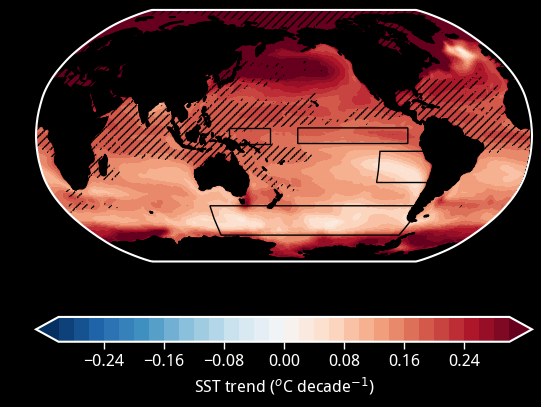

In [57]:
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
plot_background(ax)
ax.add_feature(cfeature.LAND, color='k', zorder=2)
zz = np.ma.masked_less_equal(out.pval_agreement, 0.8)
out.trend.mean('model').plot.contourf(cmap='RdBu_r', levels=np.arange(-0.3, 0.32, 0.02), extend='both', transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='horizontal', label='SST trend ($^{o}$C decade$^{-1}$)'))
ax.pcolor(xx, yy, zz, alpha=0., hatch='////', transform=ccrs.PlateCarree())
ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))


plt.savefig('./images/cmip_mmm.png', dpi=300, bbox_inches='tight')

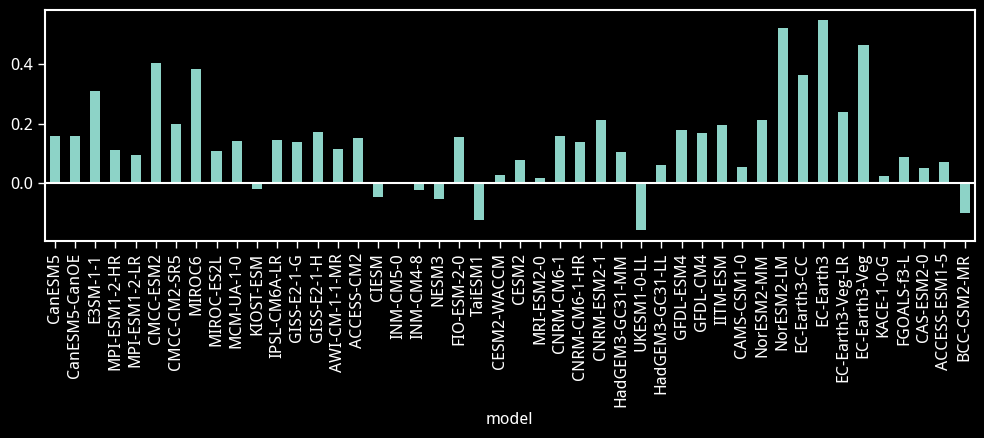

In [74]:
plt.figure(figsize=(12,3))
n34_21c = out.nino34_index.sel(time = slice('2000', '2099')).std('time')
n34_20c = out.nino34_index.sel(time = slice('1900', '1999')).std('time')
(n34_21c - n34_20c).to_series().plot.bar()
plt.axhline(0.0, color='white')

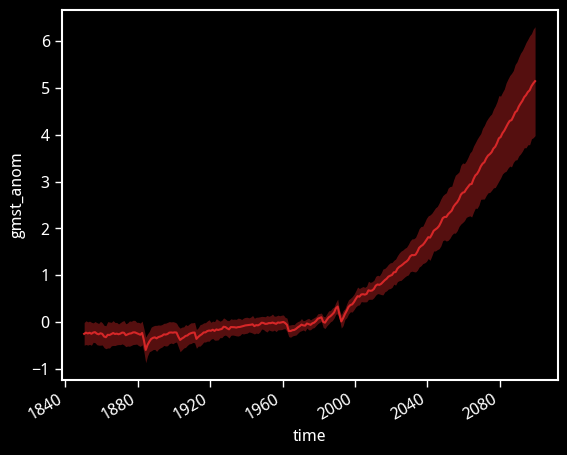

In [59]:
out.gmst_anom.mean('model').plot(color='tab:red')
plt.fill_between(out.time.to_numpy(), out.gmst_anom.mean('model') + out.gmst_anom.std('model'), out.gmst_anom.mean('model') - out.gmst_anom.std('model'), color='tab:red', alpha=0.4, lw=0.)

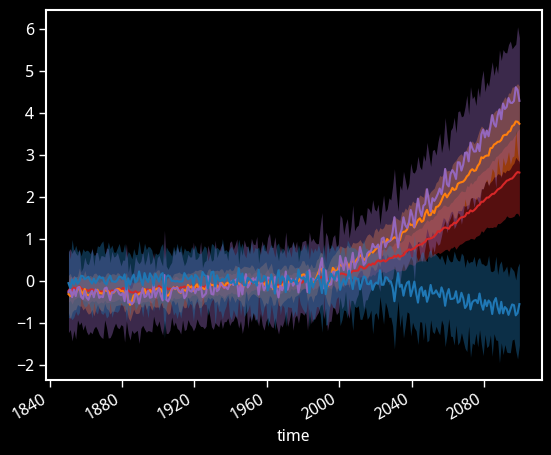

In [82]:
out.so_sst.mean('model').plot(color='tab:red')
plt.fill_between(out.time.to_numpy(), out.so_sst.mean('model') + out.so_sst.std('model'), out.so_sst.mean('model') - out.so_sst.std('model'), color='tab:red', alpha=0.4, lw=0.)
out.wp_sst.mean('model').plot(color='tab:orange')
plt.fill_between(out.time.to_numpy(), out.wp_sst.mean('model') + out.wp_sst.std('model'), out.wp_sst.mean('model') - out.wp_sst.std('model'), color='tab:orange', alpha=0.4, lw=0.)
out.ep_sst.mean('model').plot(color='tab:purple')
plt.fill_between(out.time.to_numpy(), out.ep_sst.mean('model') + out.ep_sst.std('model'), out.ep_sst.mean('model') - out.ep_sst.std('model'), color='tab:purple', alpha=0.4, lw=0.)

sst_grad = out.wp_sst - out.ep_sst
sst_grad.mean('model').plot(color='tab:blue')
plt.fill_between(out.time.to_numpy(), sst_grad.mean('model') + sst_grad.std('model'), sst_grad.mean('model') - sst_grad.std('model'), color='tab:blue', alpha=0.4, lw=0.)

In [113]:

import seaborn as sns

In [75]:
so_trends = funcs.calc_trend3d(out.so_sst.sel(time = slice('2020', '2099')), dim='time')
ep_trends = funcs.calc_trend3d(out.ep_sst.sel(time = slice('2020', '2099')), dim='time')

SignificanceResult(statistic=0.7921549278401382, pvalue=5.470545990978024e-11)

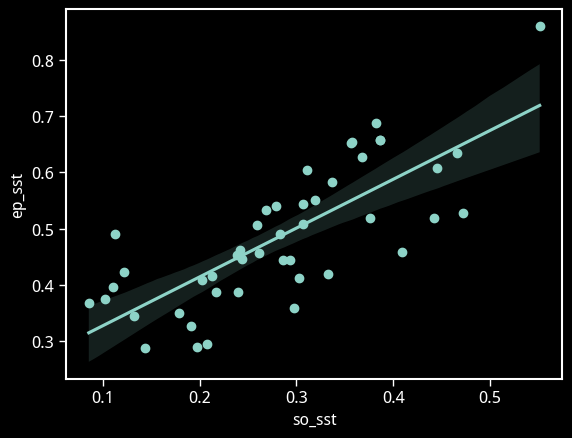

In [129]:
plt.scatter(so_trends, ep_trends)
sns.regplot(x=so_trends, y=ep_trends, scatter=False)
stats.spearmanr(so_trends, ep_trends)

In [124]:
so_warming = out.so_sst.sel(time = slice('2070', '2100')).mean('time')
gmst_warming = out.gmst_anom.sel(time = slice('2070', '2100')).mean('time')
grad_weakening = sst_grad.sel(time = slice('2070', '2100')).mean('time')

SignificanceResult(statistic=0.8524731713334156, pvalue=5.61417841566961e-14)

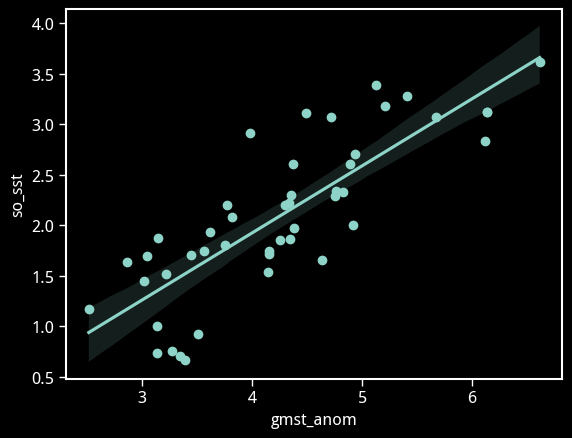

In [130]:
plt.scatter(gmst_warming, so_warming)
sns.regplot(x=gmst_warming, y=so_warming, scatter=False)
stats.spearmanr(gmst_warming, so_warming)

SignificanceResult(statistic=-0.14148266929813744, pvalue=0.3482940438212895)

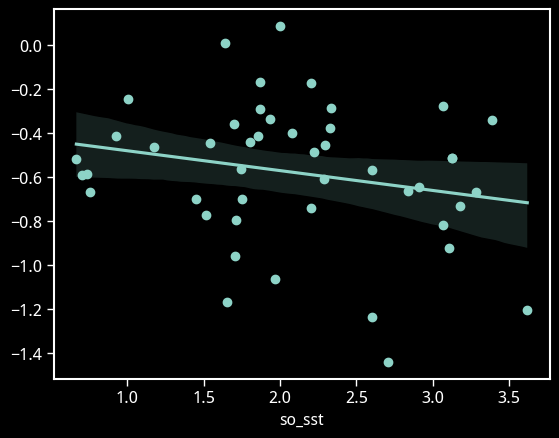

In [134]:
plt.scatter(so_warming, grad_weakening)
sns.regplot(x=so_warming, y=grad_weakening, scatter=False)
stats.spearmanr(so_warming, grad_weakening)

In [175]:
def loess1d(x, period=30):
    res = STL(x, period=period).fit()
    return res.trend

def get_toe1d(x):
    signal = loess1d(x)
    noise = x - signal
    toe = signal

def loess3d(x, dim, period=30):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

In [176]:
test = out.so_sst.isel(model = 0)
signal = loess1d(test, period=30)
noise = test - signal
sn_ratio = signal/noise

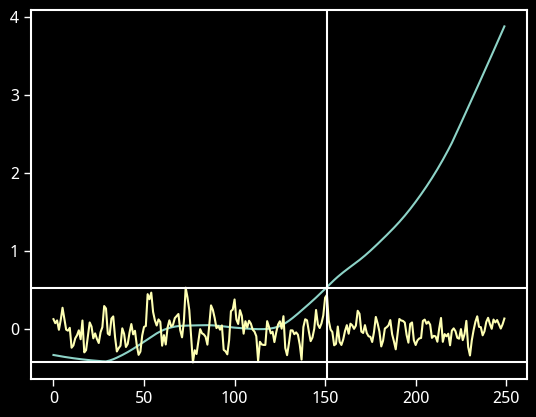

In [180]:
plt.plot(signal)
plt.plot(noise)
plt.axhline(noise.max())
plt.axhline(noise.min())
plt.axvline(151)

In [178]:
out.so_sst.drop('month')

<xarray.DataArray 'so_sst' (model: 46, time: 250)>
array([[-0.210467, -0.266404, -0.234827, ...,  3.778719,  3.885213,  4.012609],
       [-0.210467, -0.266404, -0.234827, ...,  3.778719,  3.885213,  4.012609],
       [-0.525016, -0.245263, -0.02192 , ...,  4.459621,  4.324383,  4.548012],
       ...,
       [-0.039714, -0.360939, -0.984581, ...,  2.995749,  3.574436,  3.157988],
       [ 0.023726, -0.327298, -0.457426, ...,  2.253053,  2.382106,  2.050957],
       [-0.694751, -0.505258, -0.597143, ...,  2.024962,  2.130502,  2.2621  ]])
Coordinates:
  * model    (model) object 'CanESM5' 'CanESM5-CanOE' ... 'BCC-CSM2-MR'
  * time     (time) datetime64[ns] 1850-06-01 1851-06-01 ... 2099-06-01

In [179]:
signal = loess3d(out.so_sst.drop('month'), dim='time', period=30)

ValueError: buffer source array is read-only